In [52]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pywt

from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim


In [53]:
# ============================
# Configuration
# ============================
IMG_PATH = "data/Real/bycicle.jpg"
SIGMA_LIST = [15,25,50]   # Same as SVR
WAVELETS = ['db2', 'db4', 'sym8']
LEVEL = 3
NUM_ITER = 6


In [54]:
def soft_threshold(coeffs, thresh):
    return np.sign(coeffs) * np.maximum(np.abs(coeffs) - thresh, 0)


In [55]:
def wavelet_shrinkage(img, sigma, wavelet, level):
    coeffs = pywt.wavedec2(img, wavelet=wavelet, level=level)
    thresh = sigma * np.sqrt(2 * np.log(img.size)) / 255.0
    
    coeffs_thresh = [coeffs[0]]
    for detail in coeffs[1:]:
        coeffs_thresh.append(
            tuple(soft_threshold(d, thresh) for d in detail)
        )
    return pywt.waverec2(coeffs_thresh, wavelet)


In [56]:
def multi_wavelet_pocs(noisy_img, sigma, wavelets, level, num_iter):
    x = noisy_img.copy()
    
    for _ in range(num_iter):
        for w in wavelets:
            x = wavelet_shrinkage(x, sigma, w, level)
            x = np.clip(x, 0, 1)
    return x


In [57]:
def align_images(img1, img2):
    h = min(img1.shape[0], img2.shape[0])
    w = min(img1.shape[1], img2.shape[1])
    return img1[:h, :w], img2[:h, :w]


In [58]:
if not os.path.exists(IMG_PATH):
    raise FileNotFoundError(f"{IMG_PATH} not found")

img_gt = cv2.imread(IMG_PATH, cv2.IMREAD_GRAYSCALE)
img_gt = img_gt.astype(np.float32) / 255.0

print("Loaded Bicycle:", img_gt.shape)


Loaded Bicycle: (1707, 1280)


In [59]:
import numpy as np
from skimage.metrics import structural_similarity as ssim
from skimage.metrics import peak_signal_noise_ratio as psnr

# 确保随机种子一致，这样每次跑出来的噪声都一样，方便对比
np.random.seed(42) 

print("\n=== Noisy Baseline Metrics (Benchmark) ===")
print(f"{'Sigma':<10} | {'Noisy PSNR (dB)':<18} | {'Noisy SSIM':<12}")
print("-" * 45)

# 存储基准线数据供后续画图使用
baseline_stats = []

for sigma in SIGMA_LIST:
    # 1. 生成噪声 (注意: 你的图像是 [0,1] float, 所以 sigma 要除以 255)
    noise = np.random.normal(0, sigma / 255.0, img_gt.shape).astype(np.float32)
    
    # 2. 生成含噪图像 (Noisy Input) 并截断到有效范围
    img_noisy = np.clip(img_gt + noise, 0, 1)
    
    # 3. 计算指标 (data_range=1.0 非常重要，因为你的图是 float 格式)
    # 如果 data_range 设错 (比如没填默认是None)，计算结果会不对
    current_psnr = psnr(img_gt, img_noisy, data_range=1.0)
    current_ssim = ssim(img_gt, img_noisy, data_range=1.0)
    
    # 4. 打印结果
    print(f"{sigma:<10} | {current_psnr:<18.2f} | {current_ssim:.4f}")
    
    # 5. 保存到列表 (方便你之后画图调用)
    baseline_stats.append({
        'sigma': sigma,
        'noisy_psnr': current_psnr,
        'noisy_ssim': current_ssim
    })

print("-" * 45)
print("Done measurement.")


=== Noisy Baseline Metrics (Benchmark) ===
Sigma      | Noisy PSNR (dB)    | Noisy SSIM  
---------------------------------------------
15         | 24.80              | 0.4055
25         | 20.67              | 0.2481
50         | 15.33              | 0.1151
---------------------------------------------
Done measurement.


In [50]:
results_buffer = []

for sigma in SIGMA_LIST:
    print(f"\nProcessing σ = {sigma}")
    
    np.random.seed(42)
    noise = np.random.normal(0, sigma/255.0, img_gt.shape)
    img_noisy = np.clip(img_gt + noise, 0, 1)
    
    img_denoised = multi_wavelet_pocs(
        img_noisy,
        sigma=sigma,
        wavelets=WAVELETS,
        level=LEVEL,
        num_iter=NUM_ITER
    )

    # === Align images (IMPORTANT for wavelet) ===
    img_gt_aligned, img_noisy_aligned = align_images(img_gt, img_noisy)
    _, img_denoised_aligned = align_images(img_gt, img_denoised)

    # === Metrics ===
    psnr_noisy = psnr(img_gt_aligned, img_noisy_aligned, data_range=1.0)
    psnr_denoised = psnr(img_gt_aligned, img_denoised_aligned, data_range=1.0)
    ssim_denoised = ssim(img_gt_aligned, img_denoised_aligned, data_range=1.0)
    
    results_buffer.append({
        'sigma': sigma,
        'clean': img_gt_aligned,
        'noisy': img_noisy_aligned,
        'denoised': img_denoised_aligned,
        'psnr_noisy': psnr_noisy,
        'psnr_denoised': psnr_denoised,
        'ssim_denoised': ssim_denoised
    })



Processing σ = 15

Processing σ = 25

Processing σ = 50


Saved to multiwavelet_bicycle_all_results.png


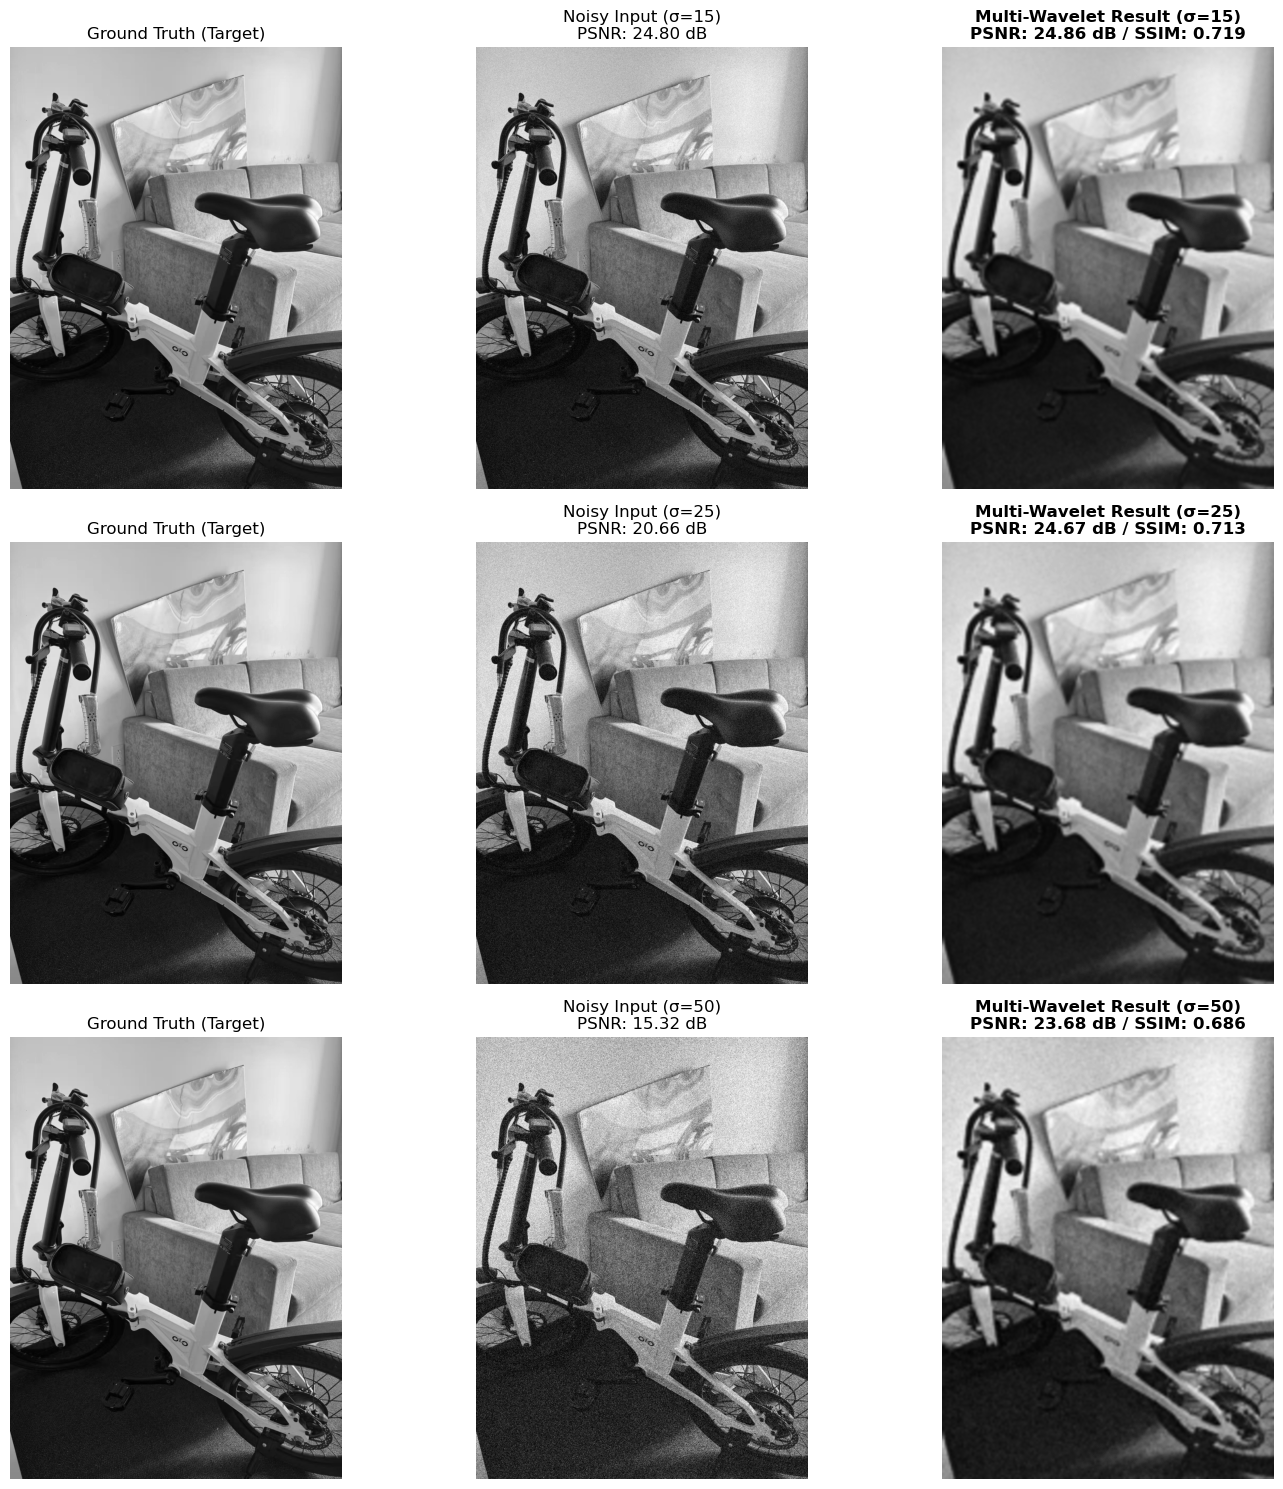

In [51]:
rows = len(results_buffer)
cols = 3

fig, axes = plt.subplots(rows, cols, figsize=(15, 5 * rows))
if rows == 1:
    axes = [axes]

for i, res in enumerate(results_buffer):
    sigma = res['sigma']
    
    # Column 1: Ground Truth
    ax1 = axes[i][0]
    ax1.imshow(res['clean'], cmap='gray')
    ax1.set_title("Ground Truth (Target)", fontsize=12)
    ax1.axis('off')
    
    # Column 2: Noisy
    ax2 = axes[i][1]
    ax2.imshow(res['noisy'], cmap='gray')
    ax2.set_title(
        f"Noisy Input (σ={sigma})\nPSNR: {res['psnr_noisy']:.2f} dB",
        fontsize=12
    )
    ax2.axis('off')
    
    # Column 3: Multi-Wavelet Result
    ax3 = axes[i][2]
    ax3.imshow(res['denoised'], cmap='gray')
    ax3.set_title(
        f"Multi-Wavelet Result (σ={sigma})\n"
        f"PSNR: {res['psnr_denoised']:.2f} dB / "
        f"SSIM: {res['ssim_denoised']:.3f}",
        fontsize=12,
        fontweight='bold'
    )
    ax3.axis('off')

plt.tight_layout()
save_path = "multiwavelet_bicycle_all_results.png"
plt.savefig(save_path)
print(f"Saved to {save_path}")
plt.show()
